# Breast Cancer Prediction Project

## Objective

building a machine learning model that can accurately predict whether a tumor is **malignant (M)** or **benign (B)** based on a set of measurements.

We'll use the dataset `Cancer_Data.csv` for this purpose.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)

## Step 1: Load the Dataset

In [5]:
df = pd.read_csv("Cancer_Data.csv")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

Shape: (569, 33)

First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimet

## Step 2: Explore the Dataset

In [6]:
print(f"\nDataset Info:")
print(f"  - Number of samples: {df.shape[0]}")
print(f"  - Number of features: {df.shape[1]}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nDiagnosis distribution:")
print(df['diagnosis'].value_counts())
print(f"\nB (Benign): {(df['diagnosis'] == 'B').sum()}")
print(f"M (Malignant): {(df['diagnosis'] == 'M').sum()}")
print(f"\nStatistical Summary:")
print(df.describe())


Dataset Info:
  - Number of samples: 569
  - Number of features: 33

Column names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Data types:
id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave 

## Step 3: Clean the Data

We'll remove any unnecessary columns and handle missing values.

In [7]:
# Drop the 'Unnamed: 32' column and 'id'
columns_to_drop = ['id']
if 'Unnamed: 32' in df.columns:
    columns_to_drop.append('Unnamed: 32')

# Check for any other unnamed columns
unnamed_cols = [col for col in df.columns if 'Unnamed' in str(col)]
columns_to_drop.extend([c for c in unnamed_cols if c not in columns_to_drop])

df_clean = df.drop(columns=columns_to_drop, errors='ignore')
print(f"Dropped columns: {columns_to_drop}")
print(f"Shape after cleaning: {df_clean.shape}")

# Check for missing values
print(f"\nMissing values after cleaning:")
print(df_clean.isnull().sum().sum())

# Drop any remaining rows with missing values
df_clean = df_clean.dropna()
print(f"Shape after dropping NaN rows: {df_clean.shape}")

Dropped columns: ['id', 'Unnamed: 32']
Shape after cleaning: (569, 31)

Missing values after cleaning:
0
Shape after dropping NaN rows: (569, 31)


## Step 4: Visualize the Data

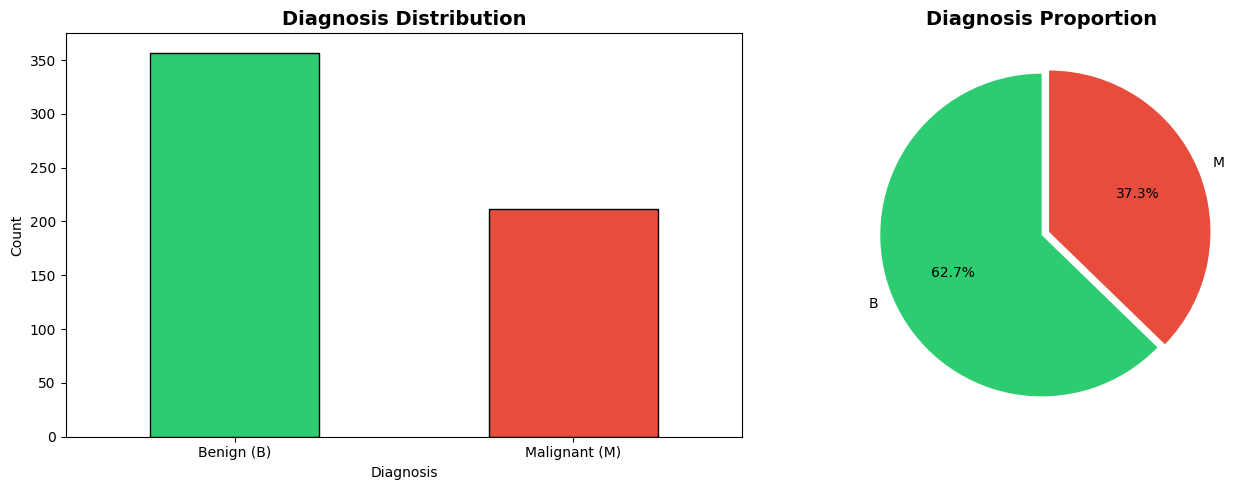

Saved: 01_diagnosis_distribution.png


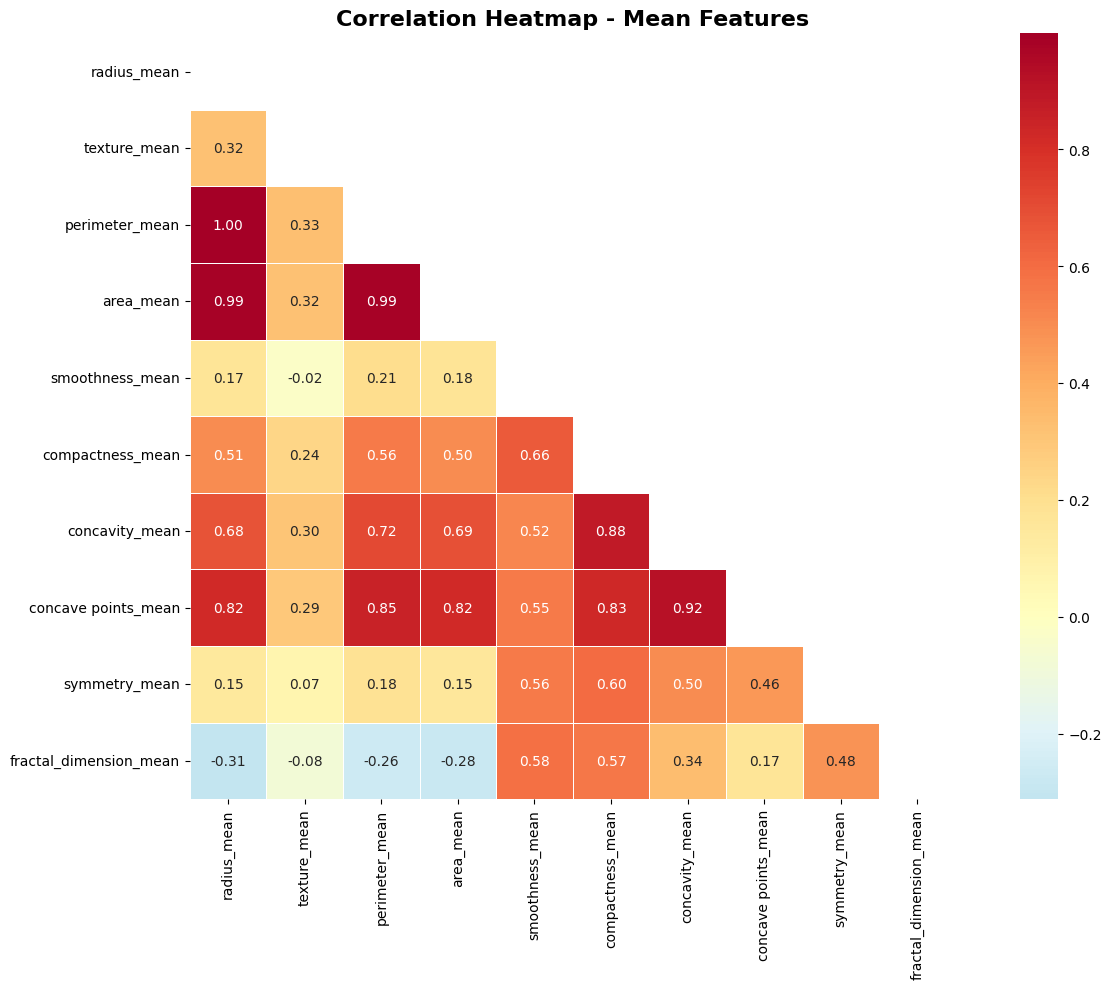

Saved: 02_correlation_heatmap.png


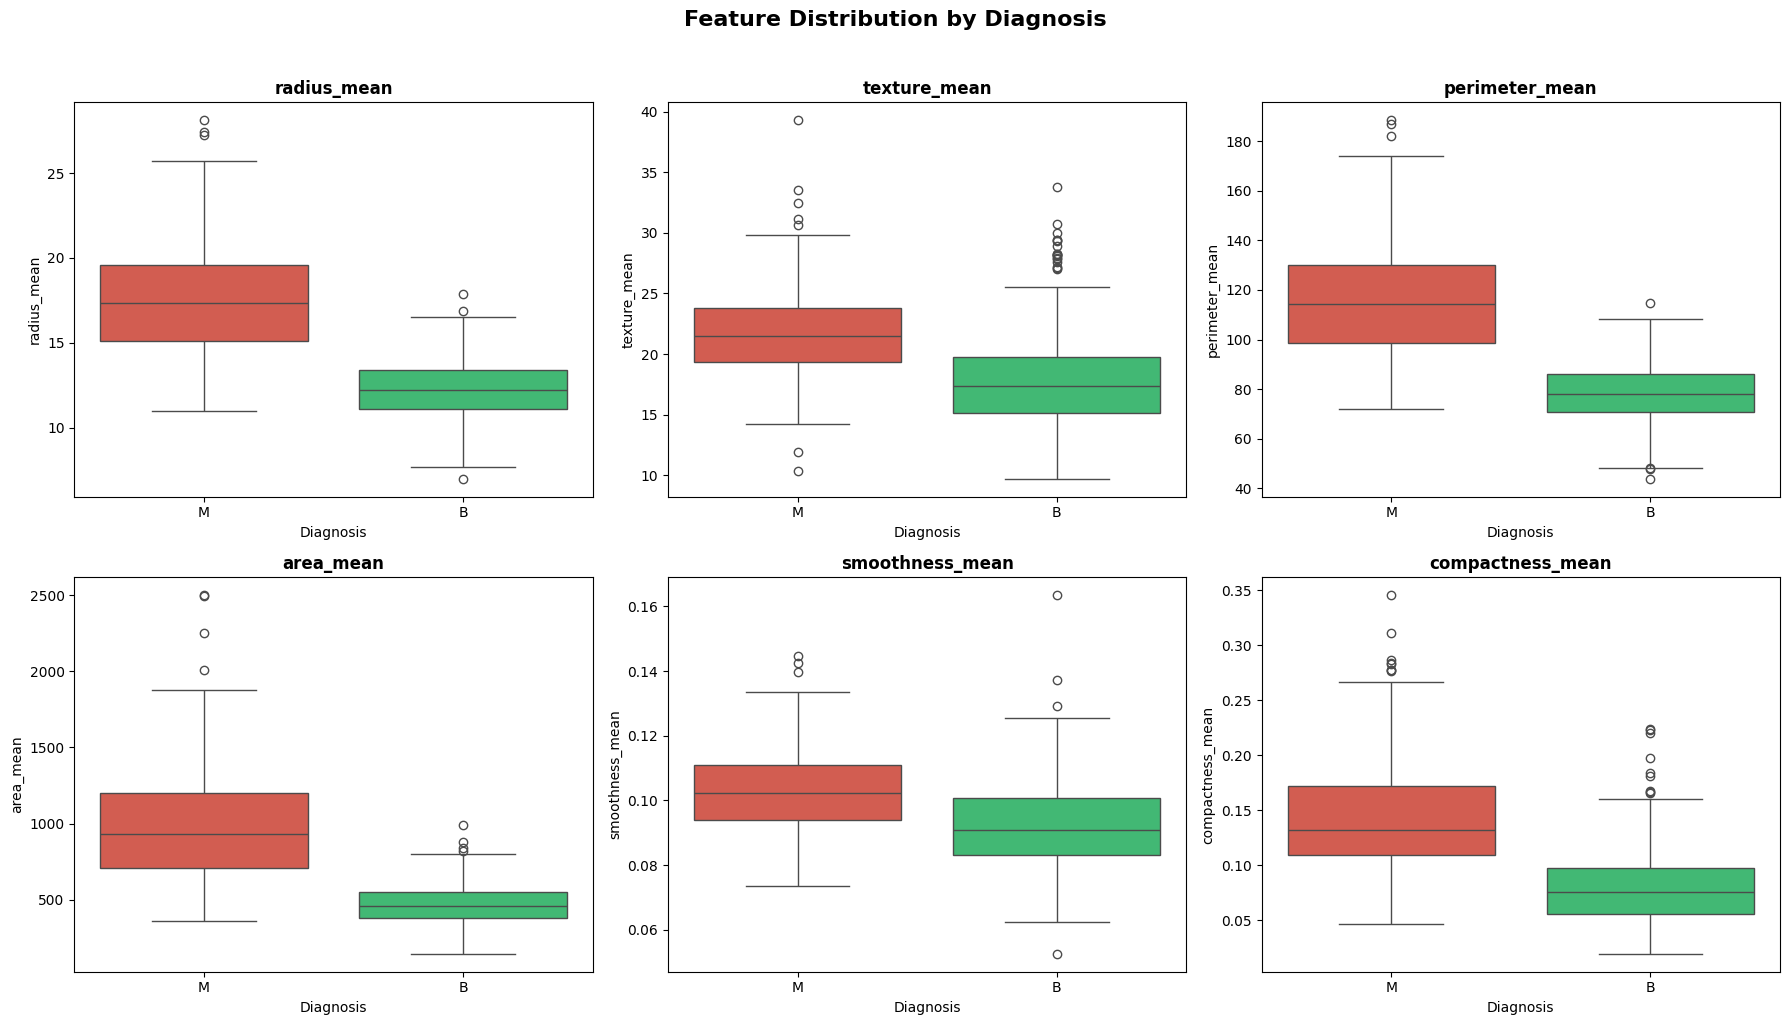

Saved: 03_boxplots.png
Generating pairplot (this may take a moment)...


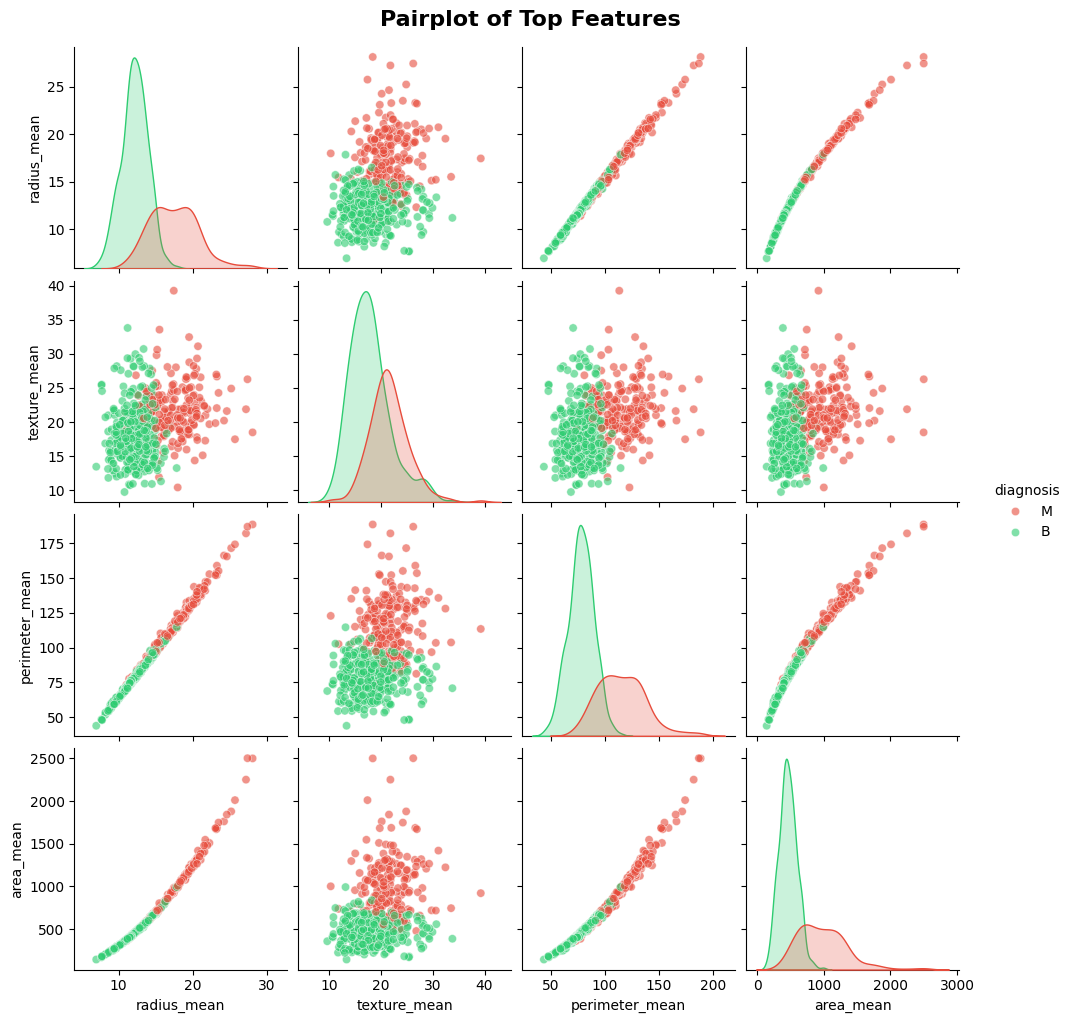

Saved: 04_pairplot.png


In [9]:
# 4a. Diagnosis Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ['#2ecc71', '#e74c3c']
df_clean['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Diagnosis Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Benign (B)', 'Malignant (M)'], rotation=0)

# Pie chart
df_clean['diagnosis'].value_counts().plot(kind='pie', ax=axes[1], colors=colors, 
                                           autopct='%1.1f%%', startangle=90,
                                           explode=[0, 0.05])
axes[1].set_title('Diagnosis Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('01_diagnosis_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_diagnosis_distribution.png")

# 4b. Correlation heatmap of mean features
mean_features = [col for col in df_clean.columns if '_mean' in col]
plt.figure(figsize=(14, 10))
corr_matrix = df_clean[mean_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Mean Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_correlation_heatmap.png")

# 4c. Box plots of key features by diagnosis
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 
                'smoothness_mean', 'compactness_mean']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    sns.boxplot(x='diagnosis', y=feature, data=df_clean, ax=axes[i], 
                palette={'B': '#2ecc71', 'M': '#e74c3c'})
    axes[i].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Diagnosis')

plt.suptitle('Feature Distribution by Diagnosis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('03_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_boxplots.png")

# 4d. Pairplot of top features
print("Generating pairplot (this may take a moment)...")
top_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'diagnosis']
g = sns.pairplot(df_clean[top_features], hue='diagnosis', 
                 palette={'B': '#2ecc71', 'M': '#e74c3c'},
                 diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairplot of Top Features', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('04_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_pairplot.png")

## Step 5: Preprocess the Data

In [10]:
# Convert diagnosis column to 0 (benign) and 1 (malignant)
le = LabelEncoder()
df_clean['diagnosis'] = le.fit_transform(df_clean['diagnosis'])
print(f"Label encoding: B -> {le.transform(['B'])[0]}, M -> {le.transform(['M'])[0]}")

# Split features and labels
X = df_clean.drop('diagnosis', axis=1)
y = df_clean['diagnosis']
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution: {dict(y.value_counts())}")

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Features scaled using StandardScaler")

Label encoding: B -> 0, M -> 1

Features shape: (569, 30)
Target shape: (569,)
Target distribution: {0: np.int64(357), 1: np.int64(212)}

Training set: 455 samples
Testing set: 114 samples
Features scaled using StandardScaler


## Step 6: Train a Machine Learning Model

In [11]:
# Define all models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42),
}

# Train and evaluate each model
results = {}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print(f"\n{'Model':<30} {'CV Accuracy':<15} {'CV Std':<10} {'Test Accuracy':<15} {'Test F1':<10} {'AUC-ROC':<10}")
print("-" * 90)

for name, model in models.items():
    # Cross-validation on training set
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    
    # Train on full training set and evaluate on test set
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
    
    results[name] = {
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': test_accuracy,
        'test_f1': test_f1,
        'test_auc': test_auc,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    
    auc_str = f"{test_auc:.4f}" if isinstance(test_auc, float) else test_auc
    print(f"{name:<30} {cv_scores.mean():.4f}        {cv_scores.std():.4f}    {test_accuracy:.4f}         {test_f1:.4f}    {auc_str}")


Model                          CV Accuracy     CV Std     Test Accuracy   Test F1    AUC-ROC   
------------------------------------------------------------------------------------------
Logistic Regression            0.9758        0.0229    0.9649         0.9512    0.9960
Random Forest                  0.9626        0.0355    0.9737         0.9630    0.9929
Support Vector Machine         0.9714        0.0242    0.9737         0.9630    0.9947
K-Nearest Neighbors            0.9647        0.0386    0.9561         0.9383    0.9823
Decision Tree                  0.9166        0.0389    0.9298         0.9048    0.9246
Gradient Boosting              0.9671        0.0264    0.9649         0.9500    0.9947
AdaBoost                       0.9735        0.0259    0.9737         0.9630    0.9854
Extra Trees                    0.9670        0.0284    0.9737         0.9630    0.9988
Naive Bayes                    0.9361        0.0363    0.9211         0.8889    0.9891
Neural Network (MLP)         

## Step 7: Evaluate the Model

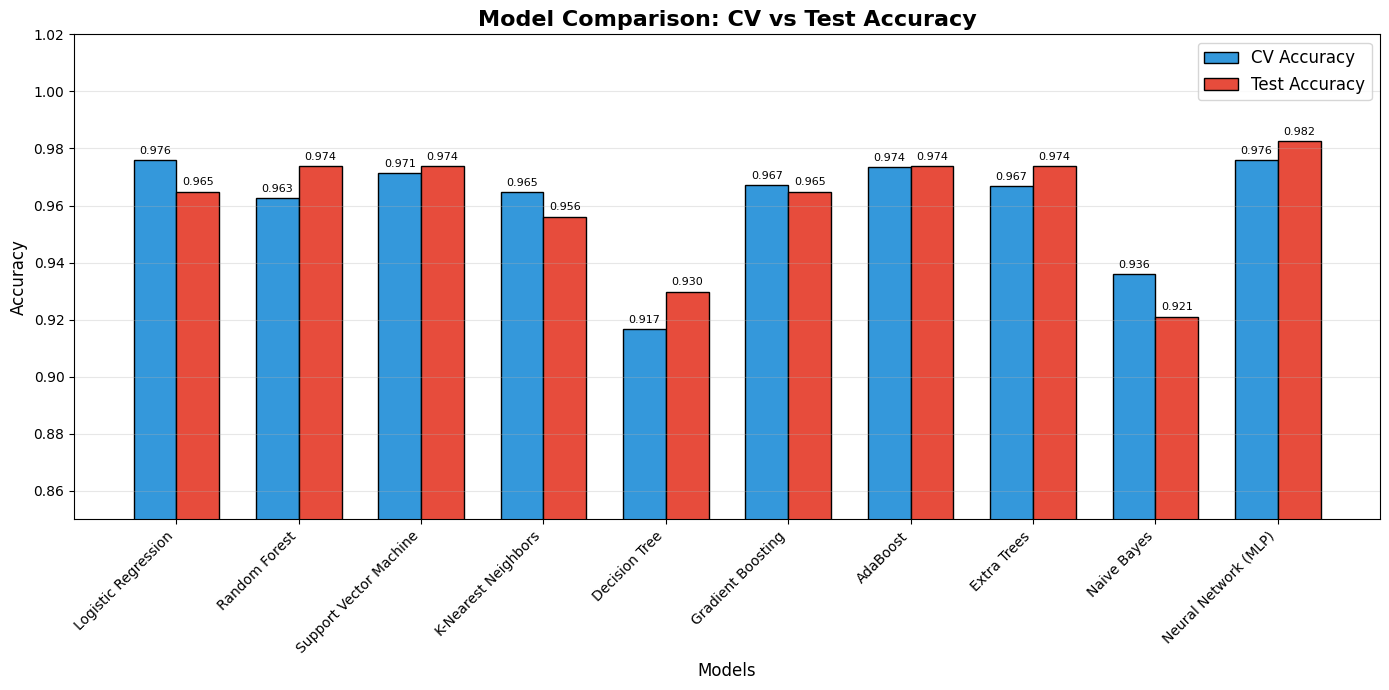

Saved: 05_model_comparison.png


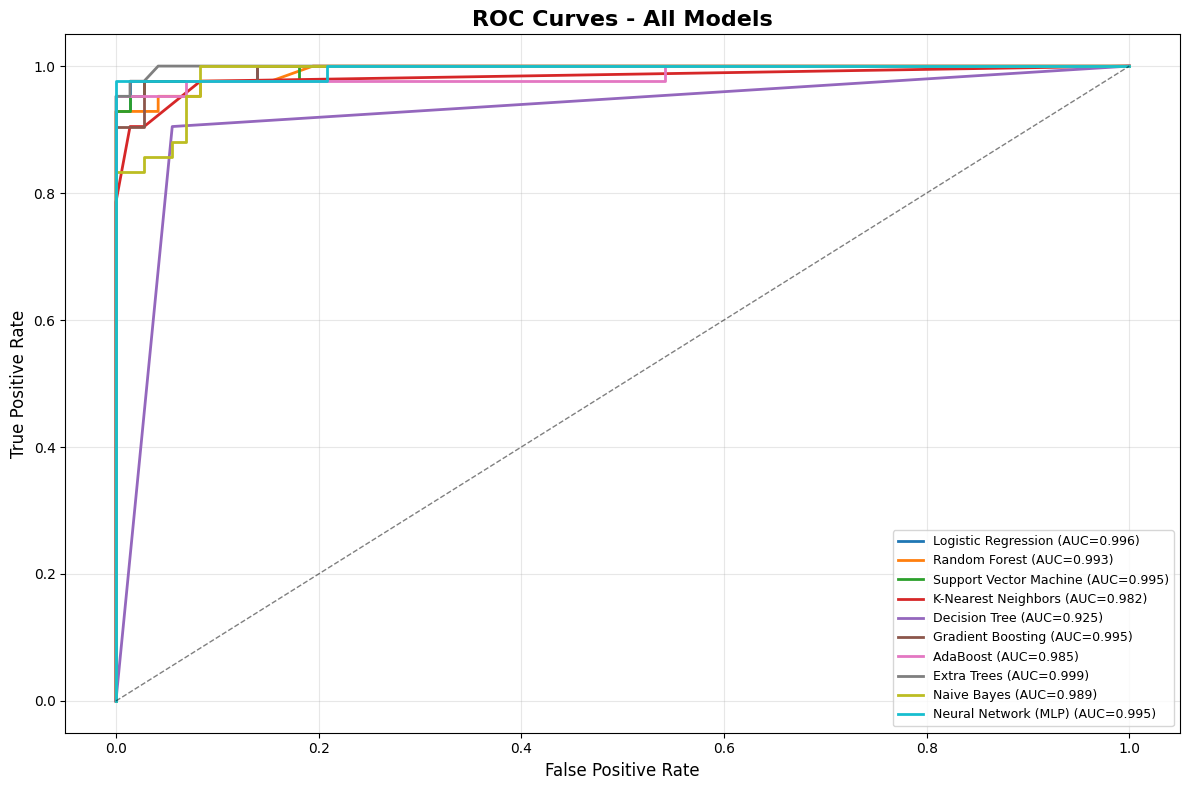

Saved: 06_roc_curves.png

  BEST MODEL: Neural Network (MLP)
  CV Accuracy: 0.9758 (+/- 0.0208)
  Test Accuracy: 0.9825
  Test F1 Score: 0.9756
  AUC-ROC: 0.9950

Confusion Matrix for Neural Network (MLP):
[[72  0]
 [ 2 40]]


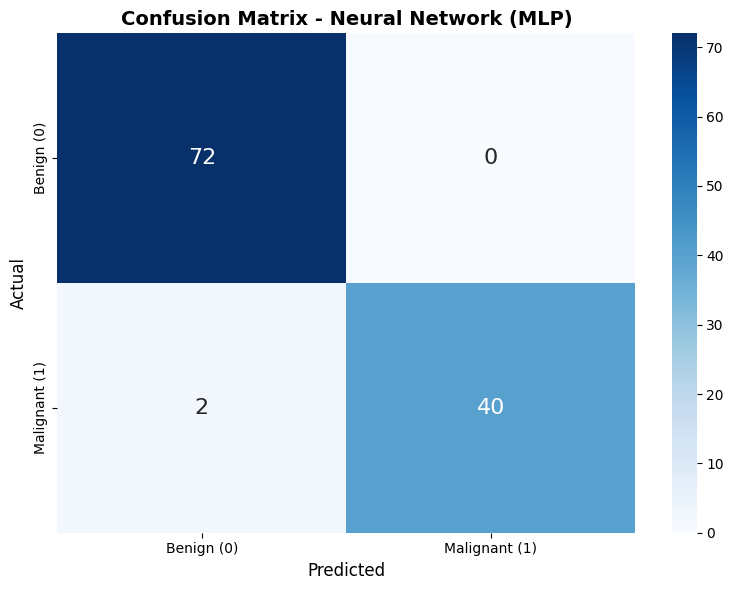

Saved: 07_confusion_matrix_best.png

Classification Report for Neural Network (MLP):
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [12]:
# 7a. Model Comparison Bar Chart
model_names = list(results.keys())
cv_means = [results[m]['cv_mean'] for m in model_names]
test_accs = [results[m]['test_accuracy'] for m in model_names]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, cv_means, width, label='CV Accuracy', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', color='#e74c3c', edgecolor='black')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison: CV vs Test Accuracy', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=12)
ax.set_ylim(0.85, 1.02)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_model_comparison.png")

# 7b. ROC Curves for all models
plt.figure(figsize=(12, 8))
for name in model_names:
    if results[name]['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
        auc = results[name]['test_auc']
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('06_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_roc_curves.png")

# 7c. Determine the best model
best_model_name = max(results, key=lambda x: results[x]['test_accuracy'])
best_result = results[best_model_name]

print(f"\n{'='*60}")
print(f"  BEST MODEL: {best_model_name}")
print(f"  CV Accuracy: {best_result['cv_mean']:.4f} (+/- {best_result['cv_std']:.4f})")
print(f"  Test Accuracy: {best_result['test_accuracy']:.4f}")
print(f"  Test F1 Score: {best_result['test_f1']:.4f}")
if isinstance(best_result['test_auc'], float):
    print(f"  AUC-ROC: {best_result['test_auc']:.4f}")
print(f"{'='*60}")

# 7d. Confusion Matrix for best model
print(f"\nConfusion Matrix for {best_model_name}:")
cm = confusion_matrix(y_test, best_result['y_pred'])
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'],
            annot_kws={'size': 16})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('07_confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 07_confusion_matrix_best.png")

# 7e. Classification Report for best model
print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, best_result['y_pred'], 
                           target_names=['Benign', 'Malignant']))

## Step 8 : Hyperparameter Tuning for Best Model

In [13]:
# Define parameter grids for top models
param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [10000]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'Support Vector Machine': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'kernel': ['rbf', 'linear', 'poly']
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10],
        'subsample': [0.8, 0.9, 1.0]
    },
    'Extra Trees': {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
    },
    'Naive Bayes': {
        'var_smoothing': np.logspace(-12, -6, 20)
    },
    'Decision Tree': {
        'max_depth': [None, 3, 5, 7, 10, 15],
        'min_samples_split': [2, 5, 10, 15],
        'min_samples_leaf': [1, 2, 4, 6],
        'criterion': ['gini', 'entropy']
    },
    'Neural Network (MLP)': {
        'hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 50, 25)],
        'activation': ['relu', 'tanh'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate': ['constant', 'adaptive'],
        'max_iter': [1000]
    }
}

# Tune the top 3 models
sorted_models = sorted(results.items(), key=lambda x: x[1]['test_accuracy'], reverse=True)
top3_names = [name for name, _ in sorted_models[:3]]

print(f"\nTuning top 3 models: {top3_names}")
print("-" * 60)

tuned_results = {}
model_constructors = {
    'Logistic Regression': LogisticRegression,
    'Random Forest': RandomForestClassifier,
    'Support Vector Machine': SVC,
    'K-Nearest Neighbors': KNeighborsClassifier,
    'Decision Tree': DecisionTreeClassifier,
    'Gradient Boosting': GradientBoostingClassifier,
    'AdaBoost': AdaBoostClassifier,
    'Extra Trees': ExtraTreesClassifier,
    'Naive Bayes': GaussianNB,
    'Neural Network (MLP)': MLPClassifier,
}

for name in top3_names:
    print(f"\nTuning: {name}...")
    
    if name in param_grids:
        base_params = {'random_state': 42} if name != 'K-Nearest Neighbors' and name != 'Naive Bayes' else {}
        if name == 'Support Vector Machine':
            base_params['probability'] = True
        
        model_class = model_constructors[name]
        grid_search = GridSearchCV(
            model_class(**base_params),
            param_grids[name],
            cv=cv,
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )
        grid_search.fit(X_train_scaled, y_train)
        
        best_model = grid_search.best_estimator_
        y_pred_tuned = best_model.predict(X_test_scaled)
        y_prob_tuned = best_model.predict_proba(X_test_scaled)[:, 1] if hasattr(best_model, 'predict_proba') else None
        
        tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
        tuned_f1 = f1_score(y_test, y_pred_tuned)
        tuned_auc = roc_auc_score(y_test, y_prob_tuned) if y_prob_tuned is not None else 'N/A'
        
        tuned_results[name] = {
            'model': best_model,
            'best_params': grid_search.best_params_,
            'best_cv_score': grid_search.best_score_,
            'test_accuracy': tuned_accuracy,
            'test_f1': tuned_f1,
            'test_auc': tuned_auc,
            'y_pred': y_pred_tuned,
            'y_prob': y_prob_tuned,
            'original_accuracy': results[name]['test_accuracy']
        }
        
        print(f"  Best Parameters: {grid_search.best_params_}")
        print(f"  Best CV Score: {grid_search.best_score_:.4f}")
        print(f"  Test Accuracy (before): {results[name]['test_accuracy']:.4f}")
        print(f"  Test Accuracy (after):  {tuned_accuracy:.4f}")
        improvement = tuned_accuracy - results[name]['test_accuracy']
        print(f"  Improvement: {improvement:+.4f}")


Tuning top 3 models: ['Neural Network (MLP)', 'Random Forest', 'Support Vector Machine']
------------------------------------------------------------

Tuning: Neural Network (MLP)...
  Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'max_iter': 1000}
  Best CV Score: 0.9758
  Test Accuracy (before): 0.9825
  Test Accuracy (after):  0.9649
  Improvement: -0.0175

Tuning: Random Forest...
  Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  Best CV Score: 0.9692
  Test Accuracy (before): 0.9737
  Test Accuracy (after):  0.9561
  Improvement: -0.0175

Tuning: Support Vector Machine...
  Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV Score: 0.9758
  Test Accuracy (before): 0.9737
  Test Accuracy (after):  0.9737
  Improvement: +0.0000


## Step 9 : Final Results Summary


  BEST TUNED MODEL: Support Vector Machine
  Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  CV Accuracy: 0.9758
  Test Accuracy: 0.9737
  Test F1 Score: 0.9630
  AUC-ROC: 0.9927

Detailed Classification Report - Support Vector Machine (Tuned):
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



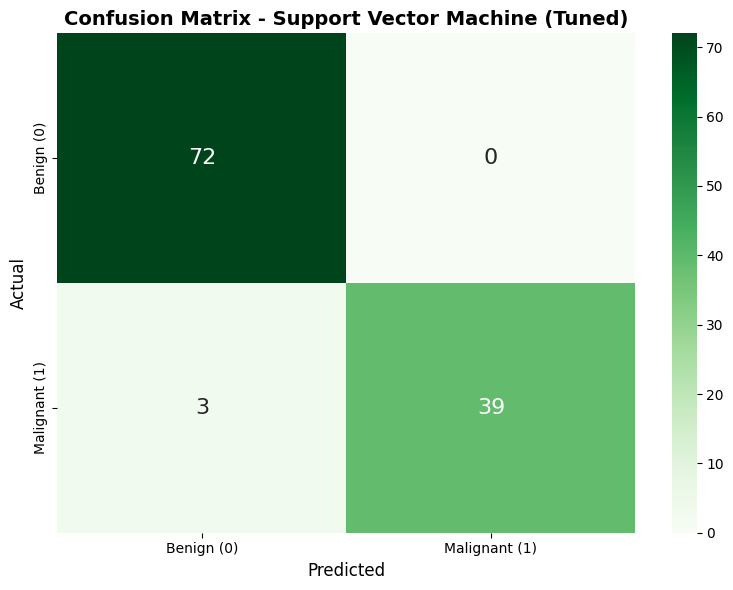

Saved: 08_confusion_matrix_tuned.png

--------------------------------------------------------------------------------
Model                          Before Tuning   After Tuning    Improvement    
--------------------------------------------------------------------------------
Neural Network (MLP)           0.9825         0.9649         -0.0175
Random Forest                  0.9737         0.9561         -0.0175
Support Vector Machine         0.9737         0.9737         +0.0000
--------------------------------------------------------------------------------


In [19]:
# Find the overall best tuned model
if tuned_results:
    best_tuned_name = max(tuned_results, key=lambda x: tuned_results[x]['test_accuracy'])
    best_tuned = tuned_results[best_tuned_name]
    
    print(f"\n{'='*60}")
    print(f"  BEST TUNED MODEL: {best_tuned_name}")
    print(f"  Best Parameters: {best_tuned['best_params']}")
    print(f"  CV Accuracy: {best_tuned['best_cv_score']:.4f}")
    print(f"  Test Accuracy: {best_tuned['test_accuracy']:.4f}")
    print(f"  Test F1 Score: {best_tuned['test_f1']:.4f}")
    if isinstance(best_tuned['test_auc'], float):
        print(f"  AUC-ROC: {best_tuned['test_auc']:.4f}")
    print(f"{'='*60}")
    
    # Classification Report
    print(f"\nDetailed Classification Report - {best_tuned_name} (Tuned):")
    print(classification_report(y_test, best_tuned['y_pred'], 
                               target_names=['Benign', 'Malignant']))
    
    # Confusion Matrix
    cm_tuned = confusion_matrix(y_test, best_tuned['y_pred'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Benign (0)', 'Malignant (1)'],
                yticklabels=['Benign (0)', 'Malignant (1)'],
                annot_kws={'size': 16})
    plt.title(f'Confusion Matrix - {best_tuned_name} (Tuned)', fontsize=14, fontweight='bold')
    plt.ylabel('Actual', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    plt.tight_layout()
    plt.savefig('08_confusion_matrix_tuned.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: 08_confusion_matrix_tuned.png")

# Comparison table: Before vs After tuning
print("\n" + "-" * 80)
print(f"{'Model':<30} {'Before Tuning':<15} {'After Tuning':<15} {'Improvement':<15}")
print("-" * 80)
for name in tuned_results:
    before = tuned_results[name]['original_accuracy']
    after = tuned_results[name]['test_accuracy']
    imp = after - before
    print(f"{name:<30} {before:.4f}         {after:.4f}         {imp:+.4f}")
print("-" * 80)

## Step 10 : Voting Ensemble of Top Models

In [21]:
# Create a voting classifier from tuned models
estimators = [(name, tuned_results[name]['model']) for name in tuned_results]
voting_clf = VotingClassifier(estimators=estimators, voting='soft')
voting_clf.fit(X_train_scaled, y_train)

y_pred_voting = voting_clf.predict(X_test_scaled)
y_prob_voting = voting_clf.predict_proba(X_test_scaled)[:, 1]

voting_accuracy = accuracy_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting)
voting_auc = roc_auc_score(y_test, y_prob_voting)

print(f"\nVoting Ensemble Results:")
print(f"  Test Accuracy: {voting_accuracy:.4f}")
print(f"  Test F1 Score: {voting_f1:.4f}")
print(f"  AUC-ROC: {voting_auc:.4f}")
print(f"\nClassification Report - Voting Ensemble:")
print(classification_report(y_test, y_pred_voting, target_names=['Benign', 'Malignant']))


Voting Ensemble Results:
  Test Accuracy: 0.9737
  Test F1 Score: 0.9630
  AUC-ROC: 0.9954

Classification Report - Voting Ensemble:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## Final Summary

In [23]:
all_final_results = {}
for name in tuned_results:
    all_final_results[f"{name} (Tuned)"] = tuned_results[name]['test_accuracy']
all_final_results["Voting Ensemble"] = voting_accuracy

# Add original un-tuned models
for name in results:
    if name not in tuned_results:
        all_final_results[name] = results[name]['test_accuracy']

# Sort by accuracy
sorted_final = sorted(all_final_results.items(), key=lambda x: x[1], reverse=True)

print(f"\n{'Rank':<6} {'Model':<35} {'Test Accuracy':<15}")
print("-" * 56)
for i, (name, acc) in enumerate(sorted_final, 1):
    marker = " ⭐" if i == 1 else ""
    print(f"{i:<6} {name:<35} {acc:.4f}{marker}")

overall_best_name = sorted_final[0][0]
overall_best_acc = sorted_final[0][1]
print(f"\n{'='*60}")
print(f"  🏆 OVERALL BEST: {overall_best_name}")
print(f"  📊 Accuracy: {overall_best_acc:.4f} ({overall_best_acc*100:.2f}%)")
print(f"{'='*60}")


Rank   Model                               Test Accuracy  
--------------------------------------------------------
1      Support Vector Machine (Tuned)      0.9737 ⭐
2      Voting Ensemble                     0.9737
3      AdaBoost                            0.9737
4      Extra Trees                         0.9737
5      Neural Network (MLP) (Tuned)        0.9649
6      Logistic Regression                 0.9649
7      Gradient Boosting                   0.9649
8      Random Forest (Tuned)               0.9561
9      K-Nearest Neighbors                 0.9561
10     Decision Tree                       0.9298
11     Naive Bayes                         0.9211

  🏆 OVERALL BEST: Support Vector Machine (Tuned)
  📊 Accuracy: 0.9737 (97.37%)
